In [73]:
import k_fail_GPS
import k_fail_MBTR
import BB_wrapper
import k_fail_prediction

import torch

# Wrapper

In [74]:
cap_n_problems = 10

cutest_wrapper = BB_wrapper.BB_cutest_collection(write_to_file="cutest_problem_selection.txt", max_dim=100, cap_n_problems=cap_n_problems)

loading problems...
0/276
skipping BOXPOWER, dimension too high
skipping SPIN2LS, dimension too high
LRCOVTYPE caused an exception while loading: module 'pycutest_cache_holder.LRCOVTYPE' has no attribute 'setup'
skipping NONCVXU2, dimension too high
skipping MODBEALE, dimension too high
skipping NONDIA, dimension too high
skipping BA-L16LS, dimension too high
loaded 10 problems


In [75]:
# evaluating n problem functions
for i in range(cap_n_problems):
    p = cutest_wrapper.problems[i]
    f = cutest_wrapper.problem_functions[i]
    print(f"idx: {i} | {p.name} | n: {p.n}: {f(torch.from_numpy(p.x0))}")

idx: 0 | SISSER | n: 2: 3.02030030003
idx: 1 | CHWIRUT2LS | n: 3: 14794.790154797307
idx: 2 | DENSCHNB | n: 2: 6.0
idx: 3 | GBRAINLS | n: 2: 41.0311021275977
idx: 4 | MGH10LS | n: 3: 4515242701191391.0
idx: 5 | QING | n: 100: 328350.0
idx: 6 | BOX3 | n: 3: 1.8845685008804969
idx: 7 | DENSCHNC | n: 2: 889.3031475218829
idx: 8 | LANCZOS3LS | n: 6: 269.7514694982056
idx: 9 | GAUSS1LS | n: 8: 7371.720578441935


# Settings

In [160]:
problem_idx = 8
k = 2
num_cpus = 4

# GPS

In [167]:
GPS_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

alg = k_fail_GPS.GPS_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), GPS_k_fail_wrapper, delta=1, tao=0.5, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path="alg_logs/GPS/testing.txt")

In [168]:
alg.log_current(message=f"k={k}")
for i in range(100):
    alg.step_default(random_rotate=True)

# MBTR

In [169]:
MBTR_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), num_cpus)

alg = k_fail_MBTR.MBTR_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_k_fail_wrapper, delta=1, mu=1e-1, eta=0.1, gamma=0.5, eps_stop=1e-1, prediction_software=k_fail_prediction.constant_prediction_software(k), log_file_path="alg_logs/MBTR/testing.txt", preferred_model_order=2)

In [170]:
alg.log_current()
for i in range(100):
    if alg.step_default():
        break

# Plotting results

for now I will just do convergence plots for one problem

In [171]:
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_log(filepath):
    fx, n_func, n_1batch, n_batch = [], [], [], []

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('k'):
                continue

            cols = line.split('|')
            if len(cols) < 5:
                continue

            try:
                fx.append(float(cols[2].strip()))        # f(x) is column index 2
            except ValueError:
                continue

            counters_match = re.search(r'\[(\d+),\s*(\d+),\s*(\d+),\s*(\d+)\]', cols[4])
            if not counters_match:
                continue
            n_func.append(int(counters_match.group(1)))
            n_1batch.append(int(counters_match.group(3)))
            n_batch.append(int(counters_match.group(4)))

    return (np.array(fx),
            np.array(n_func),
            np.array(n_1batch),
            np.array(n_batch))

def plot_convergence(filepath1, filepath2):
    fx1, n_func1, n_1batch1, n_batch1 = parse_log(filepath1)
    fx2, n_func2, n_1batch2, n_batch2 = parse_log(filepath2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].step(n_func1, fx1, where='post', label=filepath1)
    axes[0].step(n_func2, fx2, where='post', label=filepath2)
    axes[0].set_xlabel('function calls')
    axes[0].set_ylabel('f(x)')
    axes[0].set_yscale('log')
    axes[0].legend()

    axes[1].step(n_batch1,             fx1, where='post', label=f'{filepath1} all batch')
    axes[1].step(n_batch1 - n_1batch1, fx1, where='post', label=f'{filepath1} excl. 1-batch')
    axes[1].step(n_batch2,             fx2, where='post', label=f'{filepath2} all batch')
    axes[1].step(n_batch2 - n_1batch2, fx2, where='post', label=f'{filepath2} excl. 1-batch')
    axes[1].set_xlabel('batch calls')
    axes[1].set_ylabel('f(x)')
    axes[1].set_yscale('log')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# GPS vs MBTR

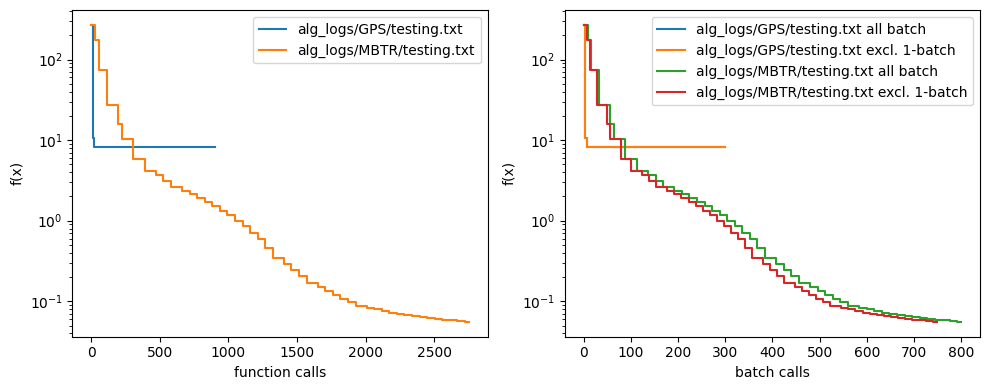

In [172]:
plot_convergence("alg_logs/GPS/testing.txt", "alg_logs/MBTR/testing.txt")